In [7]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [8]:
animals = ['BS_40','BS_41','BS_42','BS_49','BS_50','BS_51','BS_56','BS_59','BS_67','BS_70','BS_72','BS_87','BS_108','DS_15','DS_19']

In [9]:
import re

import numpy as np

_VALID_SEPARATORS = frozenset(' ,\n\t\r')


def _clean_numpy_repr(s: str) -> str:
    s = s.replace('array(', '')
    s = re.sub(r',?\s*dtype=\w+\s*', '', s)
    s = s.replace(')', '')
    return s


def str_to_np(s: str) -> np.ndarray:
    if not isinstance(s, str) or not s.strip():
        raise ValueError("Input must be a non-empty string")
    s = s.strip()
    s = _clean_numpy_repr(s)
    result, pos = _parse(s, 0)
    pos = _skip_separators(s, pos)
    if pos < len(s):
        raise ValueError(
            f"Unexpected trailing content at position {pos}: "
            f"'{s[pos:pos + 20]}{'...' if len(s) - pos > 20 else ''}'"
        )
    return _to_numpy(result)


def _skip_separators(s: str, i: int) -> int:
    while i < len(s) and s[i] in _VALID_SEPARATORS:
        i += 1
    return i


def _parse(s: str, i: int):
    i = _skip_separators(s, i)
    if i >= len(s):
        raise ValueError("Unexpected end of string")
    if s[i] == '[':
        return _parse_list(s, i)
    return _parse_atom(s, i)


def _parse_list(s: str, i: int):
    i += 1
    items = []
    while True:
        i = _skip_separators(s, i)
        if i >= len(s):
            raise ValueError("Unclosed list, missing closing ']'")
        if s[i] == ']':
            return items, i + 1
        if s[i] == '[':
            item, i = _parse_list(s, i)
        else:
            item, i = _parse_atom(s, i)
        items.append(item)


def _parse_atom(s: str, i: int):
    j = i
    while j < len(s) and s[j] not in _VALID_SEPARATORS and s[j] not in '[]':
        j += 1
    if j == i:
        raise ValueError(f"Empty token at position {i}")
    token = s[i:j]
    if token.lower() == 'nan':
        return np.nan, j
    if token == 'True':
        return True, j
    if token == 'False':
        return False, j
    try:
        return float(token), j
    except ValueError:
        raise ValueError(
            f"Invalid token at position {i}: '{token}' is not a valid number, 'nan', 'True', or 'False'"
        )


def _to_numpy(x):
    if not isinstance(x, list):
        return np.array(x)
    if len(x) == 0:
        return np.array([])

    child_is_list = [isinstance(item, list) for item in x]

    if all(child_is_list):
        children = [_to_numpy(item) for item in x]
        shapes = [a.shape for a in children]
        dtypes = [a.dtype for a in children]

        if len(set(dtypes)) > 1:
            raise ValueError(
                "Mixed types across sub-arrays: all sub-arrays must have the same dtype"
            )

        if len(set(shapes)) == 1:
            try:
                return np.array(children)
            except Exception:
                arr = np.empty(len(children), dtype=object)
                for i, c in enumerate(children):
                    arr[i] = c
                return arr
        else:
            arr = np.empty(len(children), dtype=object)
            for i, c in enumerate(children):
                arr[i] = c
            return arr

    if not any(child_is_list):
        types = {type(v) for v in x}
        if types == {bool}:
            return np.array(x, dtype=bool)
        if types <= {float}:
            return np.array(x, dtype=float)
        raise ValueError(
            "Mixed types in array: cannot mix booleans with numbers"
        )

    raise ValueError(
        "Mixed content in list: some items are arrays and some are scalars"
    )


In [10]:
class TrialInterval:
    _startTimeSamples = 0
    _endTimeSamples = 0
    _isStartTimeRelToResponse = True
    _isEndTimeRelToResponse = True
    _averageLickDelay = 0.2 * 30000

    def __init__(self,start,end,startresp,endresp):
        self._startTimeSamples = start
        self._endTimeSamples = end
        self._isStartTimeRelToResponse = startresp
        self._isEndTimeRelToResponse = endresp

    def _CalculateAvgLickDelay(self,sessionfile):
        go_responses = np.array(sessionfile.trials.response)[sessionfile.trials.go]
        go_starts = np.array(sessionfile.trials.starts)[sessionfile.trials.go]
        self._averageLickDelay = np.nanmean(go_responses - go_starts)

    def _ToTimestamp(self,sessionfile,trial):
        starttime = sessionfile.trials.starts[trial]
        if self._isStartTimeRelToResponse:
            starttime = sessionfile.trials.response[trial]
            if np.isnan(starttime):
                starttime = sessionfile.trials.starts[trial] + self._averageLickDelay
        starttime = starttime + self._startTimeSamples

        endtime = sessionfile.trials.starts[trial]
        if self._isEndTimeRelToResponse:
            endtime = sessionfile.trials.response[trial]
            if np.isnan(endtime):
                endtime = sessionfile.trials.starts[trial] + self._averageLickDelay
        endtime = endtime + self._endTimeSamples

        return [starttime,endtime]

    def _ToString(self):
        return f"Interval has start {self._startTimeSamples}, end {self._startTimeSamples}. startresp {self._isStartTimeRelToResponse} and endresp {self._isEndTimeRelToResponse}"

# def statisticalComparison(sessionfile,clust,preCondition,postCondition):
#     preInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
#     postInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
    
#     allConditions = ilep.getAllConditions(sessionfile,clust)
#     preTrials = allConditions[preCondition].trials
#     postTrials = allConditions[postCondition].trials
        
#     preTrialRates = np.full_like(preTrials,np.nan,dtype='float')
#     postTrialRates = np.full_like(postTrials,np.nan,dtype='float')    
#     for idx,trial in enumerate(preTrials):
#         start,end = preInterval._ToTimestamp(sessionfile,trial)
#         spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
#         preTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
#     for idx,trial in enumerate(postTrials):
#         start,end = postInterval._ToTimestamp(sessionfile,trial)
#         spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
#         postTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
        
#     pvalue_inc = mannwhitneyu(preTrialRates,postTrialRates,alternative='less').pvalue
#     pvalue_dec = mannwhitneyu(preTrialRates,postTrialRates,alternative='greater').pvalue
#     if pvalue_inc <= 0.05:# and np.median(postTrialRates) > np.median(preTrialRates):
#         label = 'increased'
#         pvalue = pvalue_inc
#     elif pvalue_dec <= 0.05:# and np.median(postTrialRates) < np.median(preTrialRates):
#         label = 'decreased'
#         pvalue = pvalue_dec
#     else:
#         label = 'unchanged'
#         pvalue = np.min(pvalue_inc,pvalue_dec)
#     return label,pvalue

def statisticalComparison(sessionfile,clust,preCondition,postCondition,preInterval,postInterval,iterations=5000,sample_percent=0.5,pthresh=0.95,modthresh=0.1):
    if pthresh < 0.5:
        raise Exception('pthresh cannot be less than 50%!')
    
    preInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
    postInterval = TrialInterval(0,2.5*sessionfile.meta.fs,False,False)
    
    allConditions = ilep.getAllConditions(sessionfile,clust)
    preTrials = allConditions[preCondition].trials
    postTrials = allConditions[postCondition].trials
    
    if preCondition == postCondition:
        paired=True
    else:
        paired=False
    
    preTrialRates = np.full_like(preTrials,np.nan,dtype='float')
    postTrialRates = np.full_like(postTrials,np.nan,dtype='float')
    
    for idx,trial in enumerate(preTrials):
        start,end = preInterval._ToTimestamp(sessionfile,trial)
        spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
        preTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
        
    for idx,trial in enumerate(postTrials):
        start,end = postInterval._ToTimestamp(sessionfile,trial)
        spikes = ilep.getSpikeTimes(sessionfile,clust=clust,starttime=start,endtime=end)
        postTrialRates[idx] = len(spikes) / ((end-start)/sessionfile.meta.fs)
    
    increased=0
    decreased=0
    unchanged=0
    
    for i in range(iterations):
        if paired and len(preTrialRates) != len(preTrialRates):
            raise Exception('Non-equal length paired comparison')
        if paired:
            raise Exception('Paired comparison is not yet implemented')
        else:
            preIdxs = range(len(preTrialRates))
            postIdxs = range(len(postTrialRates))
            preIdxs = np.random.permutation(preIdxs)
            postIdxs = np.random.permutation(postIdxs)
            maxIdx = int(sample_percent*min(len(preIdxs),len(postIdxs)))
            preIdxs = preIdxs[range(maxIdx)]
            postIdxs = postIdxs[range(maxIdx)]
            
        preTrialsToCompare = preTrialRates[preIdxs]
        postTrialsToCompare = postTrialRates[postIdxs]
        
        deltaTrialMean = np.mean(postTrialsToCompare - preTrialsToCompare)
        
        if deltaTrialMean >= modthresh:
            increased+=1
        elif deltaTrialMean <= -modthresh:
            decreased+=1
        else:
            unchanged+=1
            
    p_increased = increased / (increased+decreased+unchanged)
    p_decreased = decreased / (increased+decreased+unchanged)
    p_unchanged = unchanged / (increased+decreased+unchanged)
    
    print(f"inc: {p_increased}, dec: {p_decreased}, unch: {p_unchanged}")
    
    if p_increased >= pthresh:
        label='increased'
        pval = 1-p_increased
    elif p_decreased >= pthresh:
        label='decreased'
        pval = 1-p_decreased
    elif p_unchanged >= pthresh:
        label='unchanged'
        pval = 1-p_unchanged
    else:
        label='inconclusive'
        pval=1-np.max([p_increased,p_decreased,p_unchanged])
    return label,pval

In [11]:
#this function calculates pval for one cluster(one cell)
def calculate_NCR_CR_pval(sessionfile,clust):

    #convert window(100ms) in samples
    sessionfile.meta.fs #30000 samples / second from blackrock
    window = sessionfile.meta.fs * 0.1
    trials_to_use = sessionfile.trim[clust].trimmed_trials

    #create array for stimulus period
    #tone play start time
    onset_window_start_time = np.zeros(len(trials_to_use))
    for idx, trial in enumerate(trials_to_use):
        onset_window_start_time[idx] = sessionfile.trials.starts[trial]

    #tone play end time
    onset_window_end_time = onset_window_start_time + window
    #offset window start time
    offset_window_start_time = onset_window_end_time
    #offset window end time
    offset_window_end_time = offset_window_start_time + window
    #stimulus array
    stimulus_array = np.zeros([len(onset_window_start_time),2,2])
    for i in range(len(onset_window_start_time)):
        stimulus_array[i] = [[onset_window_start_time[i],onset_window_end_time[i]],
                             [offset_window_start_time[i],offset_window_end_time[i]]
                            ]

    #create array for baseline period
    base_window1_start = onset_window_start_time - 3*window
    base_window1_end = onset_window_start_time - 2*window
    base_window2_start = base_window1_end
    base_window2_end = onset_window_start_time - 1*window
    base_window3_start = base_window2_end
    base_window3_end = onset_window_start_time

    baseline_array = np.zeros([len(base_window1_start),3,2])
    for i in range(len(onset_window_start_time)):
        baseline_array[i] = [[base_window1_start[i],base_window1_end[i]],
                             [base_window2_start[i],base_window2_end[i]],
                             [base_window3_start[i],base_window3_end[i]],
                            ]

    #evaluate spike count within stimulus window
    spikecounts_stimuluswindow = np.zeros((len(onset_window_start_time),2))

    for idx, t in enumerate(stimulus_array):
        #print(t[0][0])

        #spike count from onset window
        spikecount_onsetwindow = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[0][0],endtime=t[0][1]))

        #spike count from offset window
        spikecount_offsetwindow = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[1][0],endtime=t[1][1]))

        spikecounts_stimuluswindow[idx][0]=spikecount_onsetwindow
        spikecounts_stimuluswindow[idx][1]=spikecount_offsetwindow

    #evaluate spike count within baseline window
    spikecounts_basewindow = np.zeros((len(onset_window_start_time),3))

    for idx, t in enumerate(baseline_array):
        #print(t[0][0])

        #spike count from window1
        spikecount_base_window1 = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[0][0],endtime=t[0][1]))

        #spike count from window2
        spikecount_base_window2 = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[1][0],endtime=t[1][1]))

        #spike count from window3
        spikecount_base_window3 = len(ilep.getSpikeTimes(sessionfile,clust=clust,starttime=t[2][0],endtime=t[2][1]))

        spikecounts_basewindow[idx][0]=spikecount_base_window1
        spikecounts_basewindow[idx][1]=spikecount_base_window2
        spikecounts_basewindow[idx][2]=spikecount_base_window3

    ###### CODE BELOW HERE SHOULD LOOP 5000 TIMES 
    iterations = 5000
    #spikecounts_diff_mean_arr = []

    CR_evok_appear=0
    CR_sup_appear=0
    NCR_appear=0

    for i in range(iterations):

        #1.subsampled 90% of the spike count changes from baseline,
        #2.calculated the mean of these values, repeated this process 5000 times 

        #1.
        #subsampled 90% trials
        trials = range(len(spikecounts_stimuluswindow))
        trials_perm = np.random.permutation(trials)
        trials_subsamp = trials_perm[range(int(0.9*len(trials_perm)))]

        #calculate spike count changes from baseline in the subsample
        spikecounts_diff = []
        for trial_idx in trials_subsamp:
            random_stimulus = spikecounts_stimuluswindow[trial_idx][np.random.randint(2)]
            random_base = spikecounts_basewindow[trial_idx][np.random.randint(3)]
            spikecounts_diff.append(random_stimulus-random_base)

        #2. 
        #calculate the mean of the spike counts diff  
        spikecounts_diff_mean = np.mean(spikecounts_diff)
        #calculate the # of appearance in each categotiry in 5000 iterations
        if spikecounts_diff_mean > 0.1:
            CR_evok_appear+=1
        elif spikecounts_diff_mean < -0.1:
            CR_sup_appear+=1
        else:
            NCR_appear+=1
            
    p_value_evoked = CR_evok_appear/(iterations)
    p_value_suppressed = CR_sup_appear/(iterations)
    p_value_NCR = NCR_appear/(iterations)
    return p_value_evoked, p_value_suppressed, p_value_NCR

In [12]:
def get_response_times_with_default(sessionfile):
    response_times_in_trial = (sessionfile.trials.response-sessionfile.trials.starts)
    default_response_time = np.nanmedian(response_times_in_trial)

    response_times = sessionfile.trials.response
    nogo_trials = np.isnan(response_times)
    response_times[nogo_trials] = sessionfile.trials.starts[nogo_trials]+default_response_time
    return response_times

In [13]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 2m.csv'))

In [14]:
df

,Unnamed: 0,animal,session,phase,cluster,FR modulation,trials,response times,spike times,go response,nogo response
0,0,BS_40,BS_40_10_AC.pickle,pre late,73,2.171602,[165 173 206 216 223 230 233 252 253 294 303 3...,[ nan nan nan ...,"[array([-519.03333333, -464.6 , 48.366...",[False False False False False False False Fal...,[ True True True True True True True Tr...
1,1,BS_40,BS_40_19_AC.pickle,post late,46,1.559696,[ 35 38 82 83 94 106 111 112 114 116 119 1...,[ nan nan nan ...,"[array([-702. , -418.2 , -402.7 ...",[False False False False False False False Fal...,[ True True True True True True True Tr...
2,2,BS_40,BS_40_5_AC.pickle,pre late,27,15.003600,[ 60 69 71 95 99 102 104 113 129 135 161 1...,[ nan nan nan ...,"[array([-222.46666667, 12.3 , 105.466...",[False False False False False False False Fal...,[ True True True True True True True Tr...
3,3,BS_41,BS_41_8_AC.pickle,post late,60,11.086142,[206 220 221 226 232 233 234 235 253 308 318 3...,[ nan nan nan ...,"[array([ 15.2 , 137.3 , 151.033333...",[False False False False False False False Fal...,[ True True True True True True True Tr...
4,4,BS_42,BS_42_4_AC.pickle,post early,42,31.629863,[129 221 227 241 259 289 361 395 396 404 406 4...,[ nan nan nan ...,"[array([-663.06666667, -607.36666667, -596.166...",[False False False False False False False Fal...,[ True True True True True True True Tr...
5,5,BS_49,BS_49_1_AC.pickle,pre early,4,3.396567,[ 39 43 45 47 48 51 52 56 59 64 71 ...,[ nan nan nan ...,"[array([-734.16666667, -707.63333333, -689.966...",[False False False False False False False Fal...,[ True True True True True True True Tr...
6,6,BS_70,BS_70_8_AC.pickle,post late,3,1.913440,[202 203 250 258 260 264 267 270 273 274 276 2...,[ nan nan nan ...,"[array([-732.7 , -626.36666667, -43.533...",[False False False False False False False Fal...,[ True True True True True True True Tr...
7,7,DS_15,DS_15_1_AC.pickle,pre expert,16,40.598802,[313 321 323 337 346 368 370 382 385 387 389 3...,[ nan nan nan ...,"[array([-703.26666667, -688.23333333, -681.466...",[False False False False False False False Fal...,[ True True True True True True True Tr...


# Plotting Code

In [22]:
def plot_raster_PSTH(row,ax1,ax2,Figure_start_time_ms=-250,Figure_end_time_ms=1000,xtickstouse=[0,500,1000],xticklabelstouse=None,switch_cond='NA',limitToUse=None,bw_scott_factor=3):
    buffer = 250
    sort_by_response_latency = False
    
    mn = 3.5
    spread = 2
    condition_of_interest = 'all_trials'
    ax2.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax2.tick_params(direction='out')

    trialsToPlot = str_to_np(row['trials'])
    trialSpikes = str_to_np(row['spike times'])
    trials_go_mask = str_to_np(row['go response'])
    trials_nogo_mask = str_to_np(row['nogo response'])
    responseTimes = str_to_np(row['response times'])


    
    ### Reorder trials
    # Nogo then go
    trials_nogo = trialsToPlot[trials_nogo_mask].astype(int)
    trials_go = trialsToPlot[trials_go_mask].astype(int)
    spikes_nogo = trialSpikes[trials_nogo_mask]
    spikes_go = trialSpikes[trials_go_mask]
    responses_nogo = responseTimes[trials_nogo_mask]
    responses_go = responseTimes[trials_go_mask]
    
    trialsToPlot = np.concatenate((trials_nogo,trials_go))
    trialsSpikes = np.concatenate((spikes_nogo,spikes_go))
    responseTimes = np.concatenate((responses_nogo,responses_go))
    len_nogo = len(trials_nogo)
    len_go = len(trials_go)

    #Plot Raster
    limit_to_use_nogo = len_nogo
    count = 0
    for idx,trial in enumerate(trials_nogo):
        if count < limit_to_use_nogo:
            X = trialSpikes[idx]
            Y = np.ones_like(trialSpikes[idx])*count
            mask = np.logical_and( np.greater(X,Figure_start_time_ms) , np.less(X,Figure_end_time_ms) )
            if np.sum(mask) > 0:
                X = X[mask]
                Y = Y[mask]
                this_trial_col = 'purple'
                ax1.scatter(X,Y,color=this_trial_col,s=9.,marker=2,lw=1.5,zorder=0,clip_on=False)
                count += 1
    limit_to_use_nogo = count
    
    ###
    limit_to_use_go = len_go
    count = 0
    for idx,(trial,response) in enumerate(zip(trials_go,responses_go)):
        if count < limit_to_use_go:
            X = trialSpikes[idx+len_nogo]
            Y = np.ones_like(trialSpikes[idx+len_nogo])*(count+limit_to_use_nogo)
            R = response
            mask = np.logical_and( np.greater(X,Figure_start_time_ms) , np.less(X,Figure_end_time_ms) )
            if np.sum(mask) > 0:
                X = X[mask]
                Y = Y[mask]
                this_trial_col = 'green'
                ax1.scatter(X,Y,color=this_trial_col,s=9.,marker=2,lw=1.5,zorder=0,clip_on=False)
                # print(R)
                ax1.scatter(R,count+limit_to_use_nogo,c='k',s=10)
                count += 1
    limit_to_use_go = count
    
    #Set trial limits
    max_trial_value = len(trialsToPlot)
    sequence_of_possible_axis_limits = np.array([1,2,4,6,8,10,12,16,20,30])
    idx_of_okay_limits = np.less_equal(sequence_of_possible_axis_limits,max_trial_value)
    valid_limits = sequence_of_possible_axis_limits[idx_of_okay_limits]
    if not len(valid_limits) > 0:
        return False,[]
    limit = limit_to_use_nogo+limit_to_use_go
    ax1.set_xlim([Figure_start_time_ms,Figure_end_time_ms])
    ax1.set_ylim([0,limit])
    ax1.set_yticks([])



    
    #Plot PSTH
    starttime = Figure_start_time_ms
    endtime = Figure_end_time_ms
    xrange = np.linspace(starttime,endtime,num=1000)
    trialSpikes_nogo = trialSpikes[range(len_nogo)]
    numSplits = min(10,len(trialSpikes_nogo))
    if numSplits < 2:
        return False,[] ### Return a failure
    FR = np.full((numSplits,len(xrange)),np.nan)
    kf = KFold(n_splits=numSplits)
    for idx,(_,train_index) in enumerate(kf.split(trialSpikes_nogo)):
        PSTHspikes = np.concatenate(trialSpikes_nogo[train_index])
        if len(PSTHspikes) == 0:
            FR[idx,:] = np.zeros(len(xrange))
            continue
        bw = len(PSTHspikes)**(-1./5) / bw_scott_factor
        KDE = gaussian_kde(PSTHspikes,bw_method=bw)
        FR[idx,:] = KDE.evaluate(xrange)
        FR[idx,:] = FR[idx,:] * len(PSTHspikes) / len(train_index) * 1000
    avg_FR = np.mean(FR,axis=0)
    sem_FR = sem(FR,axis=0)
    ax2.plot(xrange,avg_FR,lw=2,color='purple')
    ax2.fill_between(xrange,avg_FR-sem_FR,avg_FR+sem_FR,color='purple',alpha=0.1,zorder=-10,lw=0)


    
    #Plot PSTH
    starttime = Figure_start_time_ms
    endtime = Figure_end_time_ms
    xrange = np.linspace(starttime,endtime,num=1000)
    trialSpikes_go = trialSpikes[range(len_nogo,len_nogo+len_go)]
    numSplits = min(10,len(trialSpikes_go))
    if numSplits < 2:
        return False,[] ### Return a failure
    FR = np.full((numSplits,len(xrange)),np.nan)
    kf = KFold(n_splits=numSplits)
    for idx,(_,train_index) in enumerate(kf.split(trialSpikes_go)):
        PSTHspikes = np.concatenate(trialSpikes_go[train_index])
        if len(PSTHspikes) == 0:
            FR[idx,:] = np.zeros(len(xrange))
            continue
        bw = len(PSTHspikes)**(-1./5) / bw_scott_factor
        KDE = gaussian_kde(PSTHspikes,bw_method=bw)
        FR[idx,:] = KDE.evaluate(xrange)
        FR[idx,:] = FR[idx,:] * len(PSTHspikes) / len(train_index) * 1000 
    avg_FR = np.mean(FR,axis=0)
    sem_FR = sem(FR,axis=0)
    ax2.plot(xrange,avg_FR,lw=2,color='green')
    ax2.fill_between(xrange,avg_FR-sem_FR,avg_FR+sem_FR,color='green',alpha=0.1,zorder=-10,lw=0)

    
    #PSTH Limits
    if limitToUse is None:
        max_FR_value = np.max(avg_FR+sem_FR) * 1.1
        sequence_of_possible_axis_limits = np.array([1,2,4,6,8,10,12,16,20,30,40,50,60,80,100,120,140,150,160,180,200])
        idx_of_okay_limits = np.greater_equal(sequence_of_possible_axis_limits,max_FR_value)
        valid_limits = sequence_of_possible_axis_limits[idx_of_okay_limits]
        limit = np.min(valid_limits)
    else:
        limit  = limitToUse

    ax2.set_ylim([0,limit])
    ax2.set_yticks([0,limit])
    ax2.set_yticklabels(['0',str(limit)])
    ylab = ax2.set_ylabel('')#
    
    ### X limits
    ax1.set_xlim([starttime,endtime])
    ax2.set_xlim([starttime,endtime])
    ax1.set_xticks(np.array(xtickstouse))
    if xticklabelstouse is None:
        ax1.set_xticklabels(np.array(xtickstouse))
    else:
        ax1.set_xticklabels(xticklabelstouse)

    xlab = ax1.set_xlabel('Time (ms)')
    ax2.set_xticks([])
    
    ### Tone bar
    ax2.plot([0,100],[limit]*2,c='k',lw=2,clip_on=False,zorder=10)
        
    ### Stim bar
    ax1.plot([0,0],[0,93],linestyle='--',lw=1,color='gray',zorder=-10,clip_on=False)
    ax2.plot([0,0],ax2.get_ylim(),linestyle='--',lw=1,color='gray',zorder=-10,clip_on=False)
    
    ################################################################
    
    for axis in ['bottom','left']:
        ax1.spines[axis].set_linewidth(1.75)
        ax2.spines[axis].set_linewidth(1.75)
    ax1.tick_params(width=0)
    ax2.tick_params(width=1.75)
    for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
        ax1.get_xticklabels() + ax1.get_yticklabels()):
        item.set_fontsize(20)
    for item in ([ax2.title, ax2.xaxis.label, ax2.yaxis.label] +
        ax2.get_xticklabels() + ax2.get_yticklabels()):
        item.set_fontsize(20)

    go_spikes = [np.sum(np.logical_and(np.greater(s,-50),np.less(s,0))) for s in trialSpikes_go]
    nogo_spikes = [np.sum(np.logical_and(np.greater(s,-50),np.less(s,0))) for s in trialSpikes_nogo]
    pval = ttest_ind(go_spikes,nogo_spikes).pvalue
    if pval <= 0.05:
        ax2.set_title('p = '+str(pval))
    
    artists = [ylab,xlab]
    plt.show()
    return True,artists,pval

# Stim Rasters

0it [00:00, ?it/s]

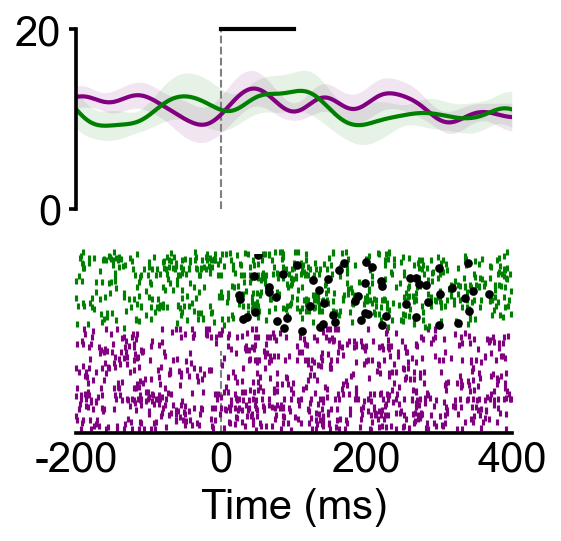

1it [00:03,  3.32s/it]

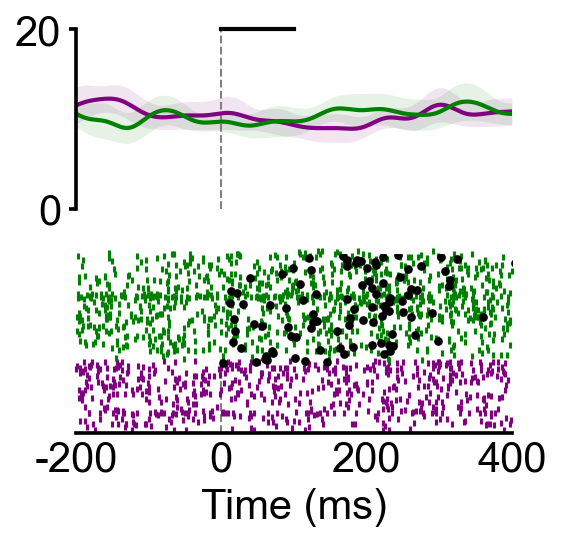

2it [00:08,  4.64s/it]

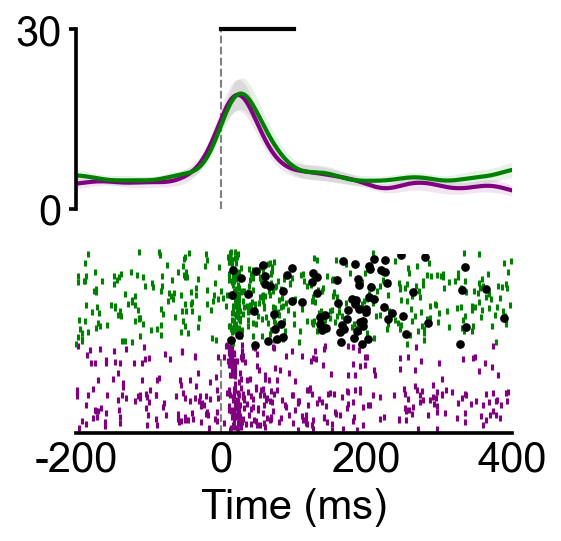

3it [00:12,  4.27s/it]

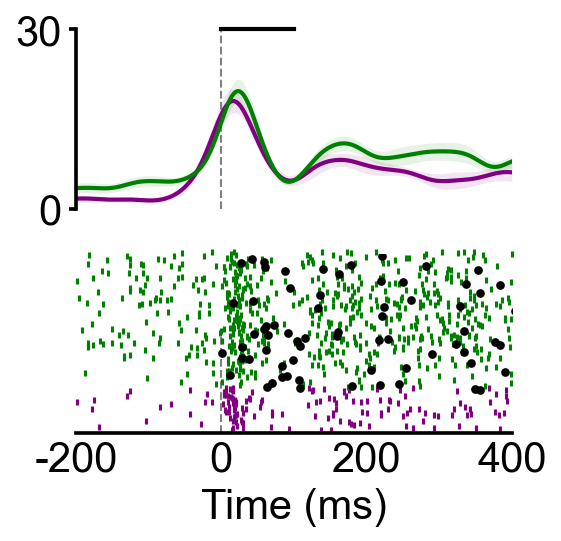

4it [00:16,  4.05s/it]

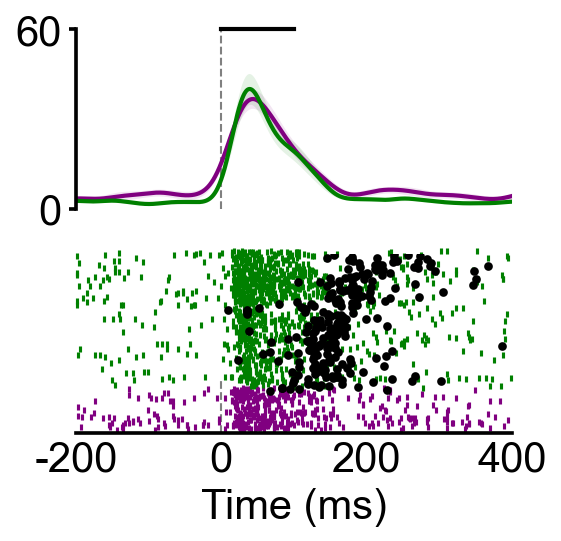

5it [00:23,  5.07s/it]

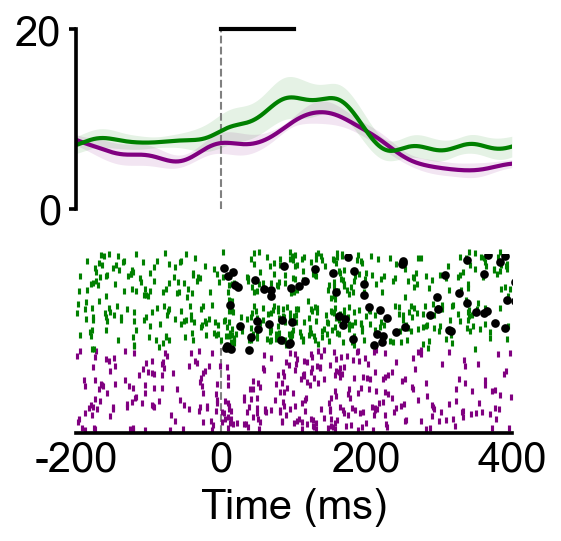

6it [00:26,  4.44s/it]

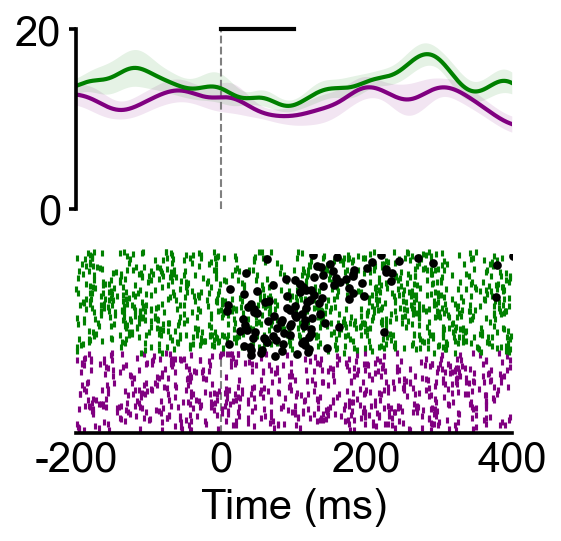

7it [00:31,  4.56s/it]

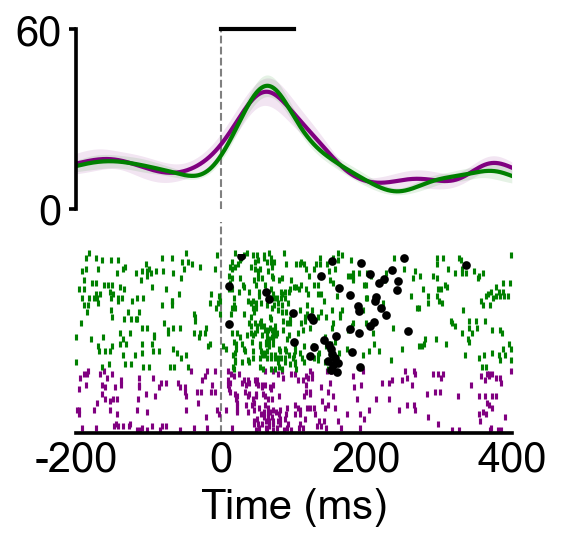

8it [00:33,  4.13s/it]


In [26]:
for row in tqdm(df.iloc):

    fig_title = ''
    session = row['session']
    clust = row['cluster']
    phase = row['phase']
    FRmod = row['FR modulation']
    
    limitToUse = None
    bw_to_use = 8
    if session == 'DS_15_1_AC.pickle' and clust in [16]:
        fig_title = 'pre nontarget CR'
        limitToUse = 60
    if session == 'BS_40_10_AC.pickle' and clust in [73]:
        fig_title = 'pre nontarget NCR'
        limitToUse = 20
    if session == 'BS_40_5_AC.pickle' and clust in [27]:
        fig_title = 'pre target CR'
        limitToUse = 30
    if session == 'BS_49_1_AC.pickle' and clust in [4]:
        fig_title = 'pre target NCR'
        limitToUse = 20
    if session == 'BS_42_4_AC.pickle' and clust in [42]:
        fig_title = 'post target CR'
        limitToUse = 60
    if session == 'BS_40_19_AC.pickle' and clust in [46]:
        fig_title = 'post target NCR'
        limitToUse = 20
    if session == 'BS_41_8_AC.pickle' and clust in [60]:
        fig_title = 'post nontarget CR'
        limitToUse = 30
    if session == 'BS_70_8_AC.pickle' and clust in [3]:
        fig_title = 'post nontarget NCR'
        limitToUse = 20

    try:
        fig = plt.figure(figsize=(3.75,3.5))
        gs = fig.add_gridspec(2,1,height_ratios=[1,1],hspace=0.25)
        
        ax3 = plt.subplot(gs[1,0]) #Raster
        ax4 = plt.subplot(gs[0,0]) #PSTH

        fst=-200
        fet=400
        xt=[-200,0,200,400]
        xtl=None
        success,artists,pval = plot_raster_PSTH(row,ax3,ax4,limitToUse=limitToUse,Figure_start_time_ms=fst,Figure_end_time_ms=fet,xtickstouse=xt,xticklabelstouse=xtl,bw_scott_factor=bw_to_use)
        if not success:
            print('Fail')

        # fig.savefig(os.path.join('..','..','Figures',f'Figure 2m {fig_title}.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

    except Exception as e:
        raise e
        print('fail')